# General

For more informations, si the documentation *Documentary Strategy*.

# Import & Configs

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /home/jeremy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/jeremy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Data Upload

In [3]:
def get_cleaned_doc_df():
    documents = []

    with open("../data/processed/clean_documents.jsonl", "r") as f:
    
        for line in f:
            documents.append(json.loads(line))

    return pd.DataFrame(documents)

In [4]:
df = get_cleaned_doc_df()
df.head()

,pmid,title,abstract,year,text,journal,mesh,keywords,publication_types,is_review,is_systematic_review,is_meta_analysis,is_guideline,evidence_level
0,42277245,Mapping radiosensitivity in glioblastoma using...,Glioblastoma multiforme (GBM) remains a devast...,2026,Mapping radiosensitivity in glioblastoma using...,Scientific reports,[],"[Glioblastoma (GBM), MR elastography (MRE), Ma...",[Journal Article],False,False,False,False,1
1,42276782,Treatment of Human Glioblastoma Multiforme in ...,The effectiveness and safety of Auger electron...,2026,Treatment of Human Glioblastoma Multiforme in ...,Journal of nuclear medicine : official publica...,[],"[197gHg, Auger electrons, convection-enhanced ...",[Journal Article],False,False,False,False,1
2,42276409,Selective inhibition of ELFN2-containing PP1 h...,Glioblastoma (GBM) frequently develops resista...,2026,Selective inhibition of ELFN2-containing PP1 h...,Cancer letters,[],"[ELFN2-containing PP1, Glioblastoma, alternati...",[Journal Article],False,False,False,False,1
3,42276258,Mitochondria-driven oxidative stress mediates ...,"Cyproconazole (CYPRO), a triazole fungicide wi...",2026,Mitochondria-driven oxidative stress mediates ...,Neurotoxicology,[],"[Cyproconazole, caspase-dependent apoptosis, m...",[Journal Article],False,False,False,False,1
4,42276218,Preclinical feasibility and validation of MRI ...,PURPOSE: Interstitial photodynamic therapy (iP...,2026,Preclinical feasibility and validation of MRI ...,Photodiagnosis and photodynamic therapy,[],"[MRI, glioblastoma, interstitial photodynamic ...",[Journal Article],False,False,False,False,1


# Sentence Splitting

In [5]:
example_text = df.iloc[0]["text"]

sentences = sent_tokenize(example_text)

sentences[:5]

['Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical modeling.',
 'Glioblastoma multiforme (GBM) remains a devastating disease with a poor prognosis.',
 "GBM progression generates mechanical forces that compromise blood vessels' functionality, impair perfusion, and create hypoxic regions, which in turn reduce radiosensitivity.",
 'While the link between hypoxia and radiosensitivity is known, a quantitative methodology to predict this effect is lacking.',
 'Here, we developed a patient-specific mechanistic mathematical model of radiotherapy that integrates Magnetic Resonance Elastography (MRE) imaging.']

# Chunker

In [6]:
def create_chunks(
    text,
    chunk_size=500,
    overlap_sentences=1
):

    sentences = sent_tokenize(text)

    chunks = []

    current_chunk = []
    current_length = 0

    for sentence in sentences:

        sentence_length = len(sentence)

        if current_length + sentence_length > chunk_size:

            chunk_text = " ".join(current_chunk)
        
            if chunk_text.strip():
        
                chunks.append(chunk_text)
        
            overlap = current_chunk[-overlap_sentences:]
        
            current_chunk = overlap.copy()
        
            current_length = sum(
                len(s) for s in current_chunk
            )

        current_chunk.append(sentence)

        current_length += sentence_length

    if current_chunk:

        chunks.append(
            " ".join(current_chunk)
        )

    return chunks

# Chunks

## Exemple

In [7]:
sample_chunks = create_chunks(
    df.iloc[0]["text"]
)

In [8]:
len(sample_chunks)

5

In [9]:
print(sample_chunks[0])

Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical modeling. Glioblastoma multiforme (GBM) remains a devastating disease with a poor prognosis. GBM progression generates mechanical forces that compromise blood vessels' functionality, impair perfusion, and create hypoxic regions, which in turn reduce radiosensitivity. While the link between hypoxia and radiosensitivity is known, a quantitative methodology to predict this effect is lacking.


In [10]:
print(sample_chunks[1])

While the link between hypoxia and radiosensitivity is known, a quantitative methodology to predict this effect is lacking. Here, we developed a patient-specific mechanistic mathematical model of radiotherapy that integrates Magnetic Resonance Elastography (MRE) imaging. The model can translate MRE-derived stiffness into spatial maps of mechanical stress and simulate subsequent events, such as compression of vessels and impaired intratumoral oxygen distribution which impacts radiosensitivity.


## Chunk all documents

In [11]:
all_chunks = []

In [12]:
for _, row in df.iterrows():

    chunks = create_chunks(
        row["text"]
    )

    for i, chunk in enumerate(chunks):

        all_chunks.append({
            "chunk_id": f'{row["pmid"]}_{i}',
        
            "pmid": row["pmid"],
            "chunk_index": i,
        
            "title": row["title"],
            "year": row["year"],
        
            "evidence_level": row["evidence_level"],
        
            "is_review": row["is_review"],
            "is_systematic_review": row["is_systematic_review"],
            "is_meta_analysis": row["is_meta_analysis"],
            "is_guideline": row["is_guideline"],
        
            "text": chunk
        })

In [13]:
chunk_df = pd.DataFrame(all_chunks)

## Exploration of chunks

In [14]:
chunk_df.columns

Index(['chunk_id', 'pmid', 'chunk_index', 'title', 'year', 'evidence_level',
       'is_review', 'is_systematic_review', 'is_meta_analysis', 'is_guideline',
       'text'],
      dtype='str')

In [15]:
chunk_df.head()

,chunk_id,pmid,chunk_index,title,year,evidence_level,is_review,is_systematic_review,is_meta_analysis,is_guideline,text
0,42277245_0,42277245,0,Mapping radiosensitivity in glioblastoma using...,2026,1,False,False,False,False,Mapping radiosensitivity in glioblastoma using...
1,42277245_1,42277245,1,Mapping radiosensitivity in glioblastoma using...,2026,1,False,False,False,False,While the link between hypoxia and radiosensit...
2,42277245_2,42277245,2,Mapping radiosensitivity in glioblastoma using...,2026,1,False,False,False,False,The model can translate MRE-derived stiffness ...
3,42277245_3,42277245,3,Mapping radiosensitivity in glioblastoma using...,2026,1,False,False,False,False,Our simulations show that biomechanical proper...
4,42277245_4,42277245,4,Mapping radiosensitivity in glioblastoma using...,2026,1,False,False,False,False,The results are compressed vessels with hypo-p...


In [16]:
len(chunk_df)

22283

In [17]:
chunk_df["chunk_length"] = (
    chunk_df["text"].apply(len)
)

In [18]:
chunk_df["chunk_length"].describe()

count    22283.000000
mean       423.734057
std         89.761336
min         45.000000
25%        377.000000
50%        428.000000
75%        471.000000
max       3521.000000
Name: chunk_length, dtype: float64

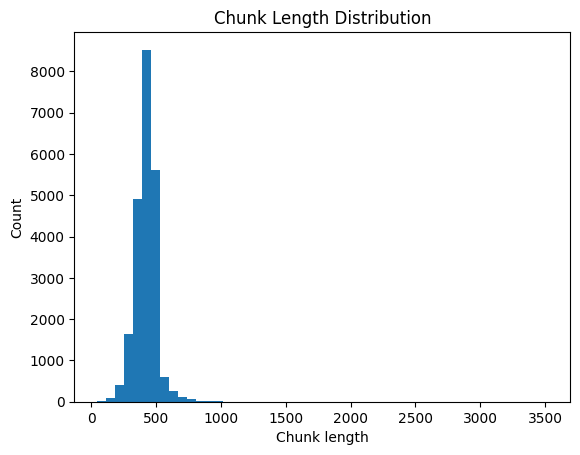

In [19]:
plt.hist(
    chunk_df["chunk_length"],
    bins=50
)

plt.xlabel("Chunk length")

plt.ylabel("Count")

plt.title("Chunk Length Distribution")

plt.show()

<Axes: ylabel='chunk_length'>

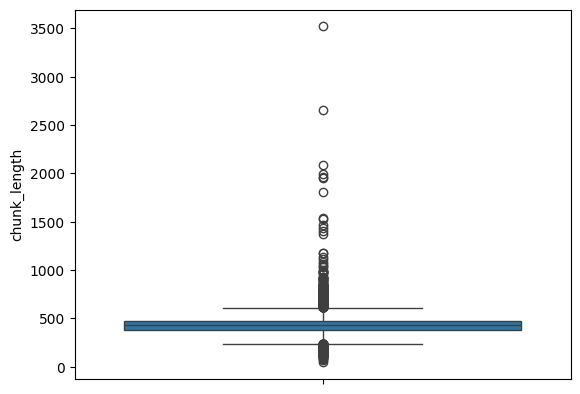

In [20]:
sns.boxplot(data=chunk_df["chunk_length"])

# Download Data

In [21]:
output_path = "../data/chunks/chunks.jsonl"

In [22]:
with open(output_path, "w") as f:

    for chunk in all_chunks:

        f.write(
            json.dumps(chunk) + "\n"
        )